<img src="https://s3-us-west-2.amazonaws.com/public.notion-static.com/7fa59d58-ba42-4de1-840a-e2e31ab9ce3b/ba416d9e-ee4d-4b7a-a9fe-a506333af2b7.png" alt="Abstract Banner" width="100%" height="200" style="object-fit: cover; border-radius: 8px;">

by: Elmar Leonard, Muhammad Rafi Andrianto and Valencia

# **Section 0: Project Initialization**

## **0.1 Importing Library**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.base import TransformerMixin

from sklearn.model_selection import cross_validate, GridSearchCV, learning_curve

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.model_selection import TimeSeriesSplit

from sklearn.preprocessing import FunctionTransformer, RobustScaler, OneHotEncoder
from category_encoders import BinaryEncoder

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC, SVC

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve

from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import average_precision_score

import pickle
import shap
import joblib
import copy
from datetime import date
import os
import sys

sys.path.append(os.path.abspath("..")) 

from Utils.serving_utils import (
    build_seller_lookup, save_seller_lookup, load_seller_lookup, refresh_seller_lookup,
    attach_seller_late_rate_frozen, calculate_haversine, convert_bool_to_int,
    get_black_friday_date, is_black_friday_or_holiday,
    aggregate_order_features, OrderFeatureAggregator,
    ServingModel, load_serving_model,
)

pd.set_option('display.max_columns', None)

## **0.2 Global Configuration**

In [17]:
DATA_DIR = 'Dataset' 
timestamp_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'shipping_limit_date']

RANDOM_STATE = 42

df = pd.read_csv(f'../{DATA_DIR}/Cleaned Data/cleaned.csv', parse_dates=timestamp_columns)
delivered = df[df["order_status"]=="delivered"]
delivered['is_late'] = (
    delivered['order_delivered_customer_date'].dt.normalize() >
    delivered['order_estimated_delivery_date'].dt.normalize()
)

pd.set_option('display.max_columns', None)
print(f"Dataframe size: {df.shape}")
print(f"Delivered Dataframe size: {delivered.shape}")

Dataframe size: (111777, 39)
Delivered Dataframe size: (108566, 40)


In [18]:
order_purchase = delivered.groupby('order_id')['order_purchase_timestamp'].transform('first')
cutoff = order_purchase.quantile(0.8)
print('Test split cutoff:', cutoff)

full_train_items = delivered[order_purchase < cutoff].copy()
test_items = delivered[order_purchase >= cutoff].copy()

order_purchase = full_train_items.groupby('order_id')['order_purchase_timestamp'].transform('first')
cutoff = order_purchase.quantile(0.75)
print('Validation split cutoff:', cutoff)

validation_items = full_train_items[order_purchase >= cutoff].copy()
train_items = full_train_items[order_purchase < cutoff].copy()
print('train orders:', train_items['order_id'].nunique(), '| validation orders:', validation_items['order_id'].nunique(), '| test orders:', test_items['order_id'].nunique())

Test split cutoff: 2018-05-22 01:07:35
Validation split cutoff: 2018-02-28 19:57:12
train orders: 57093 | validation orders: 18867 | test orders: 19110


In [19]:
DROP_COLUMNS =  ["customer_id", "order_status", "order_approved_at", "order_delivered_carrier_date", 
                 "order_delivered_customer_date", "order_item_id", "shipping_limit_date",
                 "review_score", "review_comment_message", "review_creation_date", "review_answer_timestamp"]

print('shape of train data before:', train_items.shape, ' | shape of test data before:', test_items.shape, ' | shape of validation data before:', validation_items.shape)

train_items.drop(columns=DROP_COLUMNS, inplace=True)
test_items.drop(columns=DROP_COLUMNS, inplace=True)
validation_items.drop(columns=DROP_COLUMNS, inplace=True)

print('shape of train data after:', train_items.shape, '  | shape of test data after:', test_items.shape, '  | shape of validation data after:', validation_items.shape)

shape of train data before: (65139, 40)  | shape of test data before: (21714, 40)  | shape of validation data before: (21713, 40)
shape of train data after: (65139, 29)   | shape of test data after: (21714, 29)   | shape of validation data after: (21713, 29)


In [20]:
SELLER_LOOKUP_DIR = '../Dataset/Processed Data'
os.makedirs(SELLER_LOOKUP_DIR, exist_ok=True)

MODEL_LOOKUP_DIR = '../Assets/Model'
os.makedirs(MODEL_LOOKUP_DIR, exist_ok=True)

deployed_pipeline = load_serving_model(
    model_path=f'{MODEL_LOOKUP_DIR}/deploy_pipeline.pkl',
    lookup_path=f'{SELLER_LOOKUP_DIR}/seller_lookup_latest.joblib',
)

In [21]:
order_level_test = deployed_pipeline.aggregator.transform(test_items)
y_test = order_level_test['is_late']
X_test = test_items.drop(columns="is_late")

print('shape of feature data:', X_test.shape, '  | shape of target data:', y_test.shape)

shape of feature data: (21714, 28)   | shape of target data: (19110,)


# **Section 1: Model Implementation**

## **1.1 Model Implementation**

1. **Order Approved**

    Once an order is approved, the available order and seller information is passed to the model. Only the approved order is used to make sure only orders that already paid by the customers and verified by the system that will be predicted.

2. **Predict Delivery Risk**

    The model predicts whether the order is likely to experience **late delivery**.

3. **Risk Classification**

    Orders that predicted as **late** will be categorized under two risk category, such as **Low Risk** and **High Risk** based on the selected threshold (0.076). No intervention will be done for low risk order, and only high risk order get intervention.

4. **Flagged orders**

    All orders that categorized as **High Risk** will be flagged and Olist will initiates an intervention for the associated seller, logistic partener and customers.

## **1.2 Model Limitation**

* **Data Limitations:** The dataset spans only October 2016 - August 2018, with notably low order volume in the earliest months. This limits the model's ability to fully capture seasonal patterns and may bias predictions toward periods that are overrepresented in the data.

* **Feature Limitations:** The dataset lacks contextual signals that could materially improve prediction quality. Current features rely heavily on historical information, which may not reflect a seller's most recent performance.

* **Model Behavior Limitations:** The model relies on a broad combination of ~50+ smaller features rather than a single dominant driver, making it robust but harder to translate into a simple, actionable business rule.

* **Business/Deployment Limitations:** Predictions are based on historical patterns and will not automatically reflect new operational policies, new sellers, or route changes until the model is retrained. There is also a precision-recall trade-off: optimizing for higher recall (catching more potential late deliveries) increases false positives, which translates to unnecessary intervention costs for Operations.

## **1.3 Cost Benefit Analysis**

True Negatives: 9144
False Positives: 9286
False Negatives: 149
True Positives: 531


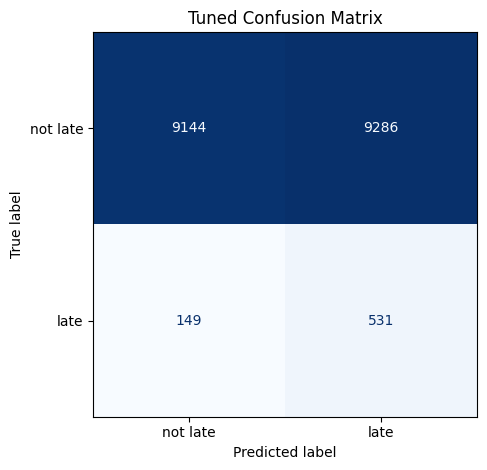

In [22]:
best_threshold = 0.076

y_test_proba = deployed_pipeline.predict_proba(test_items)[:, 1]

y_test_tuned = (y_test_proba >= best_threshold).astype(int)

cm_test = confusion_matrix(y_test, y_test_tuned)

tn, fp, fn, tp = cm_test.ravel()

print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

ConfusionMatrixDisplay(cm_test, display_labels=["not late", "late"]).plot(colorbar=False, cmap="Blues")

plt.title("Tuned Confusion Matrix")
plt.tight_layout()
plt.show()

With the test data predictions, we can calculate the net value gain to evaluate different scenarios. To quantify financial utility, Foster Provost and Tom Fawcett [Chapter 11 ("Decision Analytic Thinking") of their book *Data Science for Business*], outline a framework that converts a standard Machine Learning confusion matrix into an expected profit equation:

$$\text{Expected Benefit}=p(Y,p)\cdot b(Y,p)+p(Y,n)\cdot b(Y,n)+p(N,p)\cdot b(N,p)+p(N,n)\cdot b(N,n)$$

To match the specific case we are handling, we can simplify the framework to directly reflect our formula. Where correct non-alerts carry zero cost and missed late orders represent the baseline status quo, the expected profit equation simplifies directly to:

$$\text{Net Value}=(\text{True Positives}\times \text{Benefit})-(\text{False Positives}\times \text{Cost})$$



In [23]:
def calculate_cost_dataframe(tn, fp, fn, tp, notif_cost=0.045, failure_cost=42.5):
    total_data = tn + fp + fn + tp
    total_late_orders = tp + fn

    # ---- 1. USING MODEL ----
    paid_notif_model = (tp + fp) * notif_cost
    profit_model = tp * failure_cost            
    loss_model = fn * failure_cost
    total_model_value = profit_model - loss_model - paid_notif_model

    # ---- 2. DO NOTHING (baseline) ----
    paid_notif_none = 0
    profit_none = 0
    loss_none = total_late_orders * failure_cost 
    total_none_value = profit_none - loss_none - paid_notif_none

    # ---- 3. NOTIFY EVERYONE ----
    # every order gets an alert -> every late order is "caught" (tp_all = total_late_orders),
    # every on-time order becomes a false alarm (fp_all = total_data - total_late_orders)
    fp_all = total_data - total_late_orders
    paid_notif_all = total_data * notif_cost
    profit_all = total_late_orders * failure_cost
    loss_all = 0
    total_all_value = profit_all - loss_all - paid_notif_all

    data = {
        "Strategy": ["Using Model", "Do Nothing (Baseline)", "Notify Everyone"],
        "Notification Cost ($R)": [paid_notif_model, paid_notif_none, paid_notif_all],
        "Success Profit ($R)": [profit_model, profit_none, profit_all],
        "Failure Loss ($R)": [loss_model, loss_none, loss_all],
        "Net Value ($R)": [total_model_value, total_none_value, total_all_value]
    }

    return pd.DataFrame(data).round(2)

In [24]:
cost_df = calculate_cost_dataframe(tn, fp, fn, tp)
cost_df

,Strategy,Notification Cost ($R),Success Profit ($R),Failure Loss ($R),Net Value ($R)
0,Using Model,441.76,22567.5,6332.5,15793.24
1,Do Nothing (Baseline),0.00,0.0,28900.0,-28900.00
2,Notify Everyone,859.95,28900.0,0.0,28040.05


An evaluation of the net financial outcomes across each scenario reveals distinct performance variations. The baseline **"notify everyone" strategy yields the highest net value**, generating an estimated profit of **R$ 28,040**. Conversely, executing **no intervention** results in a projected financial loss of approximately **R$ 28,900**. 

The significant profitability of the "notify everyone" strategy stems from its exhaustive coverage: by alerting all sellers, the system maximizes successful interventions and completely eliminates the financial penalties associated with missed late deliveries (False Negatives). While our **predictive model successfully shifts the outcome from a net loss to a net profit (moving from -R$ 28,900 to +R$ 15,793)**, it still underperforms the baseline strategy. This discrepancy is primarily driven by the extremely low direct cost of dispatching notifications. 

However, a naive cost analysis that only evaluates direct communication expenses and immediate late-delivery penalties is incomplete. To measure the true business impact, we must incorporate the behavioral constraints outlined in our initial business understanding which is the **"cry wolf" effect**. 

As previously established, false alarms cause cumulative user friction. Grounded in behavioral research indicating that three to four successive false alarms prompt a user to mute or ignore alerts, we quantified the implicit cost of a false alarm ($C_{FP}$) at **R$ 14.17**. In the following section, we will calculate and layer this hypothetical cost of seller fatigue across each scenario to evaluate if the "notify everyone" strategy remains viable when accounting for long-term user desensitization.


In [25]:
def calculate_hypo_cost_dataframe(tn, fp, fn, tp, ignore_cost=14.17):
    total_data = tn + fp + fn + tp
    total_late_orders = tp + fn

    # ---- 1. USING MODEL ----
    ignore_model = fp * ignore_cost

    # ---- 2. DO NOTHING (baseline) ----
    ignore_none = 0


    # ---- 3. NOTIFY EVERYONE ----
    ignore_all = (total_data - total_late_orders)*ignore_cost


    data = {
        "Strategy": ["Using Model", "Do Nothing (Baseline)", "Notify Everyone"],
        "Ignore Cost ($R)": [ignore_model, ignore_none, ignore_all]
    }

    return pd.DataFrame(data).round(2)

In [26]:
hypo_cost_df = calculate_hypo_cost_dataframe(tn, fp, fn, tp)
hypo_cost_df

,Strategy,Ignore Cost ($R)
0,Using Model,131582.62
1,Do Nothing (Baseline),0.00
2,Notify Everyone,261153.10


Incorporating the hypothetical cost of seller fatigue fundamentally alters the financial evaluation of our strategies. The long-term behavioral costs are drastically higher under the **"notify everyone" strategy, reaching an alarming R$ 261,153.10**. In comparison, utilizing the predictive model limits this fatigue cost to **R$ 131,582.62**. 

Transitioning from the predictive model to an uncalibrated blast strategy triggers a **98.47% increase in seller fatigue costs**. This surge highlights a critical risk: because the "notify everyone" baseline creates an overwhelming volume of false alarms, the statistical probability of a seller experiencing three or more consecutive false alerts increases dramatically. Consequently, while a blanket notification strategy appears profitable on paper in the short term, it introduces severe systemic risk by rapidly accelerating user desensitization and threatening long-term seller engagement.


## **1.4 Goals: Customer Satisfaction**

Having quantified the financial and behavioral impacts of each intervention, we must evaluate whether utilizing the predictive model achieves our primary objective: improving customer satisfaction. We measure this metric using the average order review score. By applying the results of our confusion matrix which categorizes orders by intervention status and actual fulfillment outcomes (late vs. on-time), we can project the expected review scores across each scenario.

To establish a realistic baseline, our predictions are mapped directly to historical data points established during the initial business understanding phase:
*   **On-Time Orders:** Assigned an average review score of **4.0**, representing the historical average for orders delivered on schedule.

*   **Delayed Orders:** Assigned an average review score of **2.0**, reflecting the typical sharp drop in satisfaction when a delivery deadline is missed.

Using these historical benchmarks, we will simulate how each intervention strategy influences overall delivery performance and consequently shifts the platform's aggregate customer satisfaction scores.

In [27]:
def calculate_review_dataframe(tn, fp, fn, tp):
    total_data =  tn + fp + fn + tp
    
    review_model = (((fp + tp + tn)*4) + (fn * 2))/ total_data
    review_none = (((tp + tn)*4) + ((fp+ fn) * 2))/ total_data
    review_all = (total_data*4) / total_data
    
    increase_model = ((review_model-review_none)/review_none)*100
    increase_none = 0
    increase_all = ((review_all-review_none)/review_none)*100
    
    data = {
        "Strategy": ["Using Model", "Do Nothing (Baseline)", "Notify Everyone"],
        "Expected AVG Review Score": [review_model, review_none, review_all],
        "Review Score Increased from Baseline (%)": [increase_model, increase_none, increase_all],
    }

    return pd.DataFrame(data).round(2)


In [28]:
review_df = calculate_review_dataframe(tn, fp, fn, tp)
review_df

,Strategy,Expected AVG Review Score,Review Score Increased from Baseline (%)
0,Using Model,3.98,32.26
1,Do Nothing (Baseline),3.01,0.00
2,Notify Everyone,4.00,32.78


The simulation results indicate that both the predictive model and the "notify everyone" strategy significantly improve the average review score compared to the baseline scenario of no intervention. Implementing the predictive model yields a **32.26% increase in the average review score** over the baseline. Similarly, the blanket notification strategy achieves a **32.78% increase**. Crucially, the performance gap between the model and the "notify everyone" strategy is a **mere 0.52%**.

While both interventions successfully surpass our target threshold of a **30% improvement** in customer satisfaction, this minor variance demonstrates that the blanket strategy offers no substantial operational advantage in review scores. When this marginal difference is weighed against our prior financial and behavioral analyses which revealed a prohibitive **98.47% surge in seller fatigue costs** under the blanket approach. The predictive model remains the superior strategic choice for long-term platform health.


# **Section 2: Conclusion**

## **2.1 Model Conclusion**

Best model: **LightGBM (SMOTE)**

<div align="center">

| Metric | **Test Set (Final)** |
| :--- | :---: |
| **F1 Score** | **0.230** |
| **PR-AUC (AP)** | **0.242** |
| **Threshold** | **0.076** |
| **Recall (Pos)** | **87%** |
| **Precision** | **13%** |

</div>

\
The machine learning model was developed to identify orders with a high likelihood of late delivery, enabling Olist to **prioritize potentially problematic orders before the delivery deadline is missed**. After threshold optimization, the selected threshold of **0.076** achieved a **87% recall** with **13% precision** and a **0.242 PR-AUC score**. This means the model successfully captures the majority of actual late orders, although it also generates a relatively high number of false positives.

From the validation data, the model flagged **9,817 out of 19,110 orders**, consisting of **531 true positives and 9,286 false positives**. Therefore, the model is more suitable as a **screening/prioritization tool rather than a definitive classifier**. The model's main business value lies in allowing Olist to identify a broader pool of potentially risky orders and apply **targeted preventive interventions**, rather than waiting until an order becomes late.

Using SHAP analysis, there are several factors associated with high-risk orders:
* **Promised Days (Top Predictor):** A shorter promised days window tends to push predictions toward late.

* **Seller Late Rate:** Orders associated with sellers who have a higher historical late-delivery rate tend to be late.

* **Total Freight Value:** A higher freight value indicates that the order's volume is heavier or bulkier. Bigger order volumes tend to be late.

* **Purchase Month:** Several order months tend to be late (February and November), while some order months tend to be on time (August, July, June). This may be related to seasonal events, like Black Friday in November and National Carnival day in February.


## **2.2 Business Conclusion**

The analysis shows that late delivery is not a random occurrence, but is driven by identifiable order and operational characteristics. The SHAP analysis consistently highlight that delivery days-related, seller-related, product-related contribute differently to the likelihood of an order becoming late.

As the likeliness of late orders are associated to the customer satisfaction, which is reflected as review score then the model is successfully increasing **32.26% for overall rating from 3.01 rating to 3.98** while also generating **total Netvalue R$15793,24**.

# **Section 3: Recommendation**

## **3.1 Model Recommendation**

Based on the SHAP interpretation results, the model's predictive power can be systematically strengthened by integrating targeted data sources that directly address known delivery risk factors. Rather than introducing unrelated features, these additions expand upon the specific constraints the model already identifies as influential:

*   **Traffic and Seasonal Road Disruption Data:** SHAP features reveal that February purchases carry a significantly elevated risk of delayed delivery. This risk is highly correlated with major cultural events like Brazil's Carnival, where widespread street parties and parade-related road closures disrupt regional logistics. Integrating localized road-closure data or implementing a simple, cost-effective **seasonal calendar flag** would allow the model to proactively account for these predictable infrastructure bottlenecks.

*   **Real-Time Weather Forecast Data:** External disruptions such as severe storms, regional flooding, or dense fog frequently compromise delivery routes. To remain predictive, this must be sourced as a **forecast at the exact time of purchase** rather than retrospective historical weather data, ensuring the model relies only on information available at the moment of prediction.

*   **Infrastructure and Terrain Profiling:** While current distance-based metrics offer a baseline, they fail to distinguish between efficient transit routes and physically challenging terrain. Incorporating road quality indexes, elevation data, and **urban/rural classifications** will allow the model to accurately differentiate genuinely complex, hard-to-reach destinations from routes that are simply long but highly accessible.

*   **Logistics Partner and Carrier Metrics:** Operational variations such as specific carrier efficiencies and vehicle capacities, introduce uncaptured variance in delivery times. Capturing this predictive signal will require establishing **data-sharing agreements** with third-party logistics providers or sellers, as these granular carrier details are not currently tracked in the existing dataset.


## **3.2 Business Recommendation**

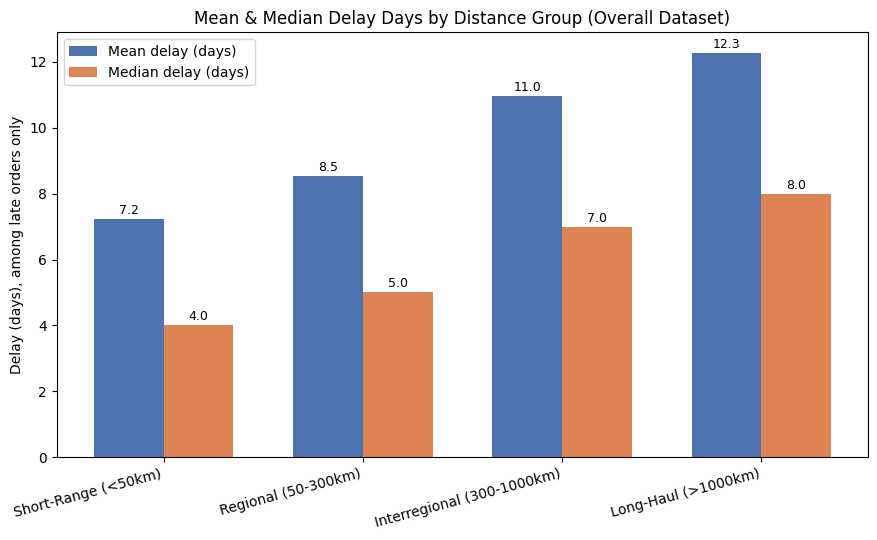

In [29]:
order = ['Short-Range (<50km)', 'Regional (50-300km)', 'Interregional (300-1000km)', 'Long-Haul (>1000km)']
mean_delay = late.groupby('distance_group', observed=True)['delay_days'].mean().reindex(order)
median_delay = late.groupby('distance_group', observed=True)['delay_days'].median().reindex(order)

fig, ax = plt.subplots(figsize=(9, 5.5))

x = range(len(order))
width = 0.35
ax.bar([i - width/2 for i in x], mean_delay.values, width, label='Mean delay (days)', color='#4C72B0')
ax.bar([i + width/2 for i in x], median_delay.values, width, label='Median delay (days)', color='#DD8452')

for i, v in enumerate(mean_delay.values):
    if not np.isnan(v):
        ax.text(i - width/2, v + 0.15, f'{v:.1f}', ha='center', fontsize=9)

for i, v in enumerate(median_delay.values):
    if not np.isnan(v):
        ax.text(i + width/2, v + 0.15, f'{v:.1f}', ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(order, rotation=15, ha='right')
ax.set_ylabel('Delay (days), among late orders only')
ax.set_title('Mean & Median Delay Days by Distance Group (Overall Dataset)')
ax.legend()

plt.tight_layout()
plt.show()

Implement a **proactive intervention workflow** for orders flagged as high-risk:

1. **Flag high-risk orders**
   Use the predictive model to identify orders with a high probability of late delivery.

2. **Notify sellers**
   Send an automated notification to the seller and request immediate action to prevent further delays.

3. **Track shipment & contact logistics partners**
   Monitor the flagged shipment and coordinate with the logistics partner when the delivery is at risk of exceeding the promised date.

4. **Adjust delivery expectations when necessary**
   When a delay cannot be prevented, update the estimated delivery timeline to provide a more realistic expectation and reduce unexpected customer dissatisfaction. This is done by adjusting the estimated delivery days with adding extra days to the estimated delivery day based on distance.
   
<div align="center">

| Distance | Added estimated days |
| :--- | :---: |
| **Short Range** | 4 days |
| **Regional** | 5 days |
| **Interregional** | 7 days |
| **Long haul** | 8 days |

</div>

\
5. **Notify customers & provide support**
   Proactively inform affected customers about potential delays and provide a channel to answer their questions or concerns.

This workflow enables Olist to identify delivery risks earlier, intervene before orders become late, and manage customer expectations when delays are unavoidable.
